#Setup

###Imports


In [99]:
import os
import requests
import time
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

###Connect to GPU

In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


### Connect to drive and define paths

In [101]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

drive_dir = "/content/drive/MyDrive/KP_MODEL"
os.makedirs(drive_dir, exist_ok=True)

checkpoint_path_rnn= os.path.join(drive_dir, "shakespeare_rnn.pth")
checkpoint_path_lstm=os.path.join(drive_dir, "shakespeare_lstm.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Download Shakespeare Data

In [102]:
cache_dir = "./tmp"
os.makedirs(cache_dir, exist_ok=True)

dataset_file_name = "shakespeare.txt"
dataset_file_origin = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"

file_path = os.path.join(cache_dir, dataset_file_name)

if not os.path.exists(file_path):
    print("Downloading dataset ...")
    data = requests.get(dataset_file_origin).text
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(data)
    print("Download complete.")
else:
    print("Dataset already exists.")

Dataset already exists.


#Load the Text & Build Vocabulary

###Analyze the dataset

In [103]:
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Text characters length:", len(text))

Text characters length: 1115394


In [104]:
# Take a look at the first 300 characters in text.
print(text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


###Character vocabulary

In [105]:
# The unique characters in the text
chars = sorted(list(set(text)))
vocab_size = len(chars)

print("Unique chars:", vocab_size)
print(chars)

Unique chars: 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


###Vectorize the text

In [106]:
# Map characters to their indices in vocabulary.
char2idx = {char: index for index, char in enumerate(chars)}

print('{')
for char, _ in zip(char2idx, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')



{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '$' :   3,
  '&' :   4,
  "'" :   5,
  ',' :   6,
  '-' :   7,
  '.' :   8,
  '3' :   9,
  ':' :  10,
  ';' :  11,
  '?' :  12,
  'A' :  13,
  'B' :  14,
  'C' :  15,
  'D' :  16,
  'E' :  17,
  'F' :  18,
  'G' :  19,
  ...
}


In [107]:
# Map character indices to characters from vacabulary.
idx2char = {index:char for char,index in char2idx.items()}
print(idx2char)

{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


###Encode the Full Text

In [108]:
# Convert chars in text to indices.
encoded = torch.tensor([char2idx[char] for char in text], dtype=torch.long)

print("Encoded shape:", encoded.shape)


Encoded shape: torch.Size([1115394])


In [109]:
# Show a few samples before & after encoding
num_examples = 200   # number of characters to preview

original_sample = text[:num_examples]
encoded_sample = encoded[:num_examples]

print("\nOriginal characters:")
print(repr(original_sample))

print("\nEncoded indices:")
print(encoded_sample.tolist())


Original characters:
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you'

Encoded indices:
[18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43, 43, 42, 1, 39, 52, 63, 1, 44, 59, 56, 58, 46, 43, 56, 6, 1, 46, 43, 39, 56, 1, 51, 43, 1, 57, 54, 43, 39, 49, 8, 0, 0, 13, 50, 50, 10, 0, 31, 54, 43, 39, 49, 6, 1, 57, 54, 43, 39, 49, 8, 0, 0, 18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 37, 53, 59, 1, 39, 56, 43, 1, 39, 50, 50, 1, 56, 43, 57, 53, 50, 60, 43, 42, 1, 56, 39, 58, 46, 43, 56, 1, 58, 53, 1, 42, 47, 43, 1, 58, 46, 39, 52, 1, 58, 53, 1, 44, 39, 51, 47, 57, 46, 12, 0, 0, 13, 50, 50, 10, 0, 30, 43, 57, 53, 50, 60, 43, 42, 8, 1, 56, 43, 57, 53, 50, 60, 43, 42, 8, 0, 0, 18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 18, 47, 56, 57, 58, 6, 

###Define Constants

In [110]:
# The maximum length sentence we want for a single input in characters.
sequence_length =100
batch_size = 64

examples_per_epoch = len(text) // (sequence_length + 1)

print('examples_per_epoch:', examples_per_epoch)

examples_per_epoch: 11043


#Create Dataset

### Split data into training and test sets 85/15

In [111]:
split = int(0.85 * len(encoded))

train_data = encoded[:split]
test_data  = encoded[split:]


###Dataset class

In [112]:
class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

###DataLoader

In [113]:
dataset = CharDataset(train_data, sequence_length)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [114]:
# For each sequence, duplicate and shift it to form the input and target text
xb, yb = next(iter(data_loader))
print("Batch input shape:", xb.shape)
print("Batch target shape:", yb.shape)

Batch input shape: torch.Size([64, 100])
Batch target shape: torch.Size([64, 100])


In [115]:
# Decode a few sequences to inspect them
num_examples_to_show = 3

for i in range(num_examples_to_show):
    inp = ''.join(idx2char[idx.item()] for idx in xb[i])
    tgt = ''.join(idx2char[idx.item()] for idx in yb[i])

    print(f"\nExample {i+1}:")
    print("Input sequence:")
    print(repr(inp[:100]))   # print first 120 chars only

    print("\nTarget sequence:")
    print(repr(tgt[:100]))


Example 1:
Input sequence:
"s of heaven; on whom it will, it will;\nOn whom it will not, so; yet still 'tis just.\n\nLUCIO:\nWhy, ho"

Target sequence:
" of heaven; on whom it will, it will;\nOn whom it will not, so; yet still 'tis just.\n\nLUCIO:\nWhy, how"

Example 2:
Input sequence:
"t to be shown,\nBut to rejoice in splendor of mine own.\n\nLADY CAPULET:\nNurse, where's my daughter? ca"

Target sequence:
" to be shown,\nBut to rejoice in splendor of mine own.\n\nLADY CAPULET:\nNurse, where's my daughter? cal"

Example 3:
Input sequence:
'd won;\nHis hands were guilty of no kindred blood,\nBut bloody with the enemies of his kin.\nO Richard!'

Target sequence:
' won;\nHis hands were guilty of no kindred blood,\nBut bloody with the enemies of his kin.\nO Richard! '


#RNN

###Define a Simple RNN Model

In [116]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.rnn(x, hidden)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch):
        return torch.zeros(1, batch, self.hidden_dim).to(device)


###Training Setup for RNN



In [117]:
rnn_model = RNNModel(vocab_size).to(device)

rnn_loss_fn = nn.CrossEntropyLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)

###Training RNN With Early Stopping

In [118]:
# TRAINING LOOP (TRAIN-LOSS EARLY STOP)
rnn_patience = 4
rnn_epochs   = 100
skip_training = True

# RESUME IF CHECKPOINT EXISTS
if os.path.exists(checkpoint_path_rnn):
    checkpoint = torch.load(checkpoint_path_rnn, map_location=device)

    rnn_model.load_state_dict(checkpoint["model_state"])
    rnn_optimizer.load_state_dict(checkpoint["optimizer_state"])

    rnn_train_losses    = checkpoint["train_losses"]
    best_rnn_train_loss = checkpoint["best_train_loss"]
    rnn_wait            = checkpoint["wait"]
    start_epoch         = checkpoint["epoch"] + 1
    if rnn_wait >= rnn_patience-1:
        print("Early stopping was already triggered previously. Not resuming training.")
        skip_training = True  # <--- STOP TRAINING
    else:
        print("Resuming RNN training from epoch:", start_epoch)
else:
    print("No RNN checkpoint found. Starting fresh.")
    rnn_train_losses    = []
    best_rnn_train_loss = float("inf")
    rnn_wait            = 0
    start_epoch         = 1

if not skip_training:
  for epoch in range(start_epoch, rnn_epochs + 1):
      rnn_model.train()
      total_loss = 0.0
      steps = 0

      for x, y in data_loader:
          x = x.to(device)
          y = y.to(device)

          hidden = rnn_model.init_hidden(x.size(0))  # RNN hidden state

          rnn_optimizer.zero_grad()
          logits, hidden = rnn_model(x, hidden)

          loss = rnn_loss_fn(
              logits.reshape(-1, vocab_size),
              y.reshape(-1)
          )

          loss.backward()
          rnn_optimizer.step()

          total_loss += loss.item()
          steps += 1

      train_loss = total_loss / steps
      rnn_train_losses.append(train_loss)

      print(f"[RNN] Epoch {epoch}/{rnn_epochs} | Train Loss: {train_loss:.4f} | Perplexity: {math.exp(train_loss):.2f}")

      # EARLY STOPPING BASED ON TRAIN LOSS
      if train_loss <= best_rnn_train_loss:
          best_rnn_train_loss = train_loss

          # save full checkpoint to Google Drive
          torch.save({
              "epoch": epoch,
              "model_state": rnn_model.state_dict(),
              "optimizer_state": rnn_optimizer.state_dict(),
              "best_train_loss": best_rnn_train_loss,
              "wait": rnn_wait,
              "train_losses": rnn_train_losses,
          }, checkpoint_path_rnn)

          print("   → Saved RNN checkpoint to Google Drive.")
      else:
          rnn_wait += 1
          print(f"   → No improvement. Patience {rnn_wait}/{rnn_patience}")
          if rnn_wait >= rnn_patience:
              print("RNN early stopping triggered (training loss).")
              break

Early stopping was already triggered previously. Not resuming training.


###PLOT RNN TRAINING LOSS

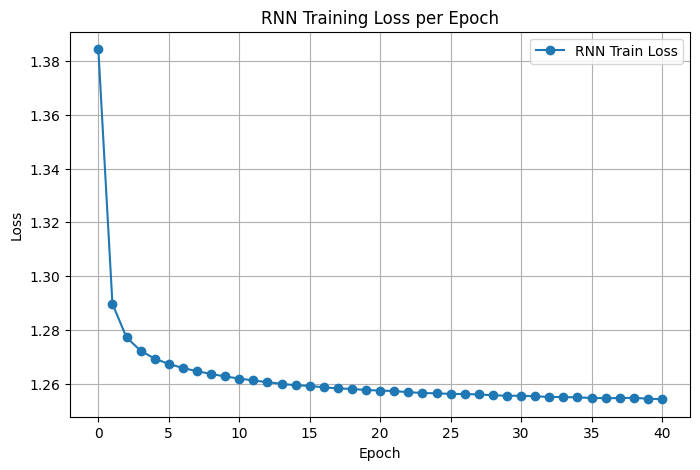

In [119]:
# PLOT RNN TRAINING LOSS
plt.figure(figsize=(8,5))
plt.plot(rnn_train_losses, marker='o', label="RNN Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()

#Text Generation

In [120]:
def sample_logits(logits, temperature=1.0):
    logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, 1).item()

def generate(model, start="ROMEO:", length=500, temperature=0.8):
    model.eval()

    input_ids = torch.tensor([[char2idx[c] for c in start]], dtype=torch.long).to(device)
    hidden = model.init_hidden(1)

    generated = list(start)

    with torch.no_grad():
        for _ in range(length):
            logits, hidden = model(input_ids, hidden)
            last_logits = logits[0, -1]
            next_id = sample_logits(last_logits, temperature)
            generated.append(idx2char[next_id])

            input_ids = torch.tensor([[next_id]], dtype=torch.long).to(device)

    return "".join(generated)



###Generate Sample With RNN


In [121]:
print(generate(rnn_model, start="ROMEO:\n", length=600, temperature=0.7))


ROMEO:
Here comes here intest proclaim the fearful do I fall I come to see him to death.

First Murderer:
I will lose our company.

KING LEWIS XI:
Be
Ratress of a king.

BRUTUS:
Now, let with his princely state to see them speak'st, she is some ill pass'd the daughter than the deeds in vile proclamation of thee!
Deather malice to heary-morest;
And for the court.

POLIXENES:
Speak thou wilt he shall in the voices,
When I do hear your garden to be set us
And what your house
May is a gentleman to him.
But, they are alone.

COMINIUS:
By nothing bless'd him well, that thou hast unful have prevent equal da


# LSTM

In [122]:
class LSTMTextGen(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embed = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch):
        h = torch.zeros(self.num_layers, batch, self.hidden_dim).to(device)
        c = torch.zeros(self.num_layers, batch, self.hidden_dim).to(device)
        return (h, c)


###LSTM Training Setup

In [123]:
# NEW LSTM MODEL + OPTIMIZER
lstm_model = LSTMTextGen(vocab_size).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
lstm_loss_fn = nn.CrossEntropyLoss()

# SEPARATE STORAGE LISTS
lstm_train_losses = []


###LSTM Early Stopping Training Loop

In [124]:
lstm_patience = 4
lstm_epochs = 100
skip_training = True


# RESUME CHECKPOINT IF EXISTS
# ------------------------------------------------------------
if os.path.exists(checkpoint_path_lstm):
    chkpt = torch.load(checkpoint_path_lstm, map_location=device)
    lstm_model.load_state_dict(chkpt["model_state"])
    lstm_optimizer.load_state_dict(chkpt["optimizer_state"])
    start_epoch = chkpt["epoch"] + 1
    best_lstm_train_loss = chkpt["best_train_loss"]
    lstm_wait = chkpt["wait"]
    lstm_train_losses = chkpt["train_losses"]
    if lstm_wait >= lstm_patience-1:
      print("Early stopping was already triggered previously at",start_epoch,". Not resuming training.")
      skip_training = True  # <--- STOP TRAINING
    else:
      print("Resuming training from epoch:", start_epoch)
else:
    start_epoch = 1
    best_lstm_train_loss = float('inf')
    lstm_wait = 0
    lstm_train_losses = []
    print("No checkpoint found. Starting fresh.")

if not skip_training:
  for epoch in range(start_epoch, lstm_epochs + 1):
      lstm_model.train()
      total_loss = 0
      steps = 0

      for x, y in data_loader:
          x, y = x.to(device), y.to(device)

          hidden = lstm_model.init_hidden(x.size(0))

          lstm_optimizer.zero_grad()
          logits, hidden = lstm_model(x, hidden)

          loss = lstm_loss_fn(logits.reshape(-1, vocab_size), y.reshape(-1))
          loss.backward()
          lstm_optimizer.step()

          total_loss += loss.item()
          steps += 1

      train_loss = total_loss / steps
      lstm_train_losses.append(train_loss)

      print(f"[LSTM] Epoch {epoch}/{lstm_epochs} | Train Loss: {train_loss:.4f}")

      # EARLY STOPPING BASED ON TRAINING LOSS
      if train_loss <= best_lstm_train_loss:
          best_lstm_train_loss = train_loss\

          # SAVE CHECKPOINT TO GOOGLE DRIVE
          torch.save({
              "epoch": epoch,
              "model_state": lstm_model.state_dict(),
              "optimizer_state": lstm_optimizer.state_dict(),
              "best_train_loss": best_lstm_train_loss,
              "wait": lstm_wait,
              "train_losses": lstm_train_losses
          }, checkpoint_path_lstm)

          print(" -> Saved checkpoint to Google Drive.")

      else:
          lstm_wait += 1
          print(f" -> No improvement. Patience {lstm_wait}/{lstm_patience}")
          if lstm_wait >= lstm_patience:
              print("Early stopping triggered!")
              break

Resuming training from epoch: 49


###PLOT LSTM TRAINING LOSS

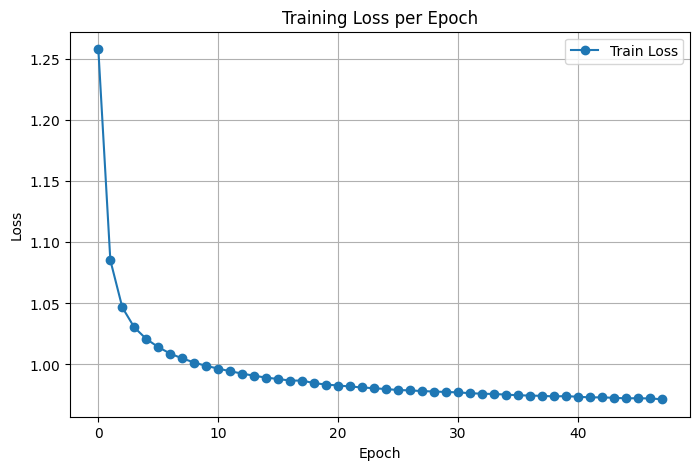

In [125]:
plt.figure(figsize=(8,5))
plt.plot(lstm_train_losses, marker='o', label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()

###Generate Sample With LSTM


In [126]:
print(generate(lstm_model, start="ROMEO:\n", length=500, temperature=0.7))


ROMEO:
Yes, Herm, madam, so much on the other, I must come?
And witch my son, of any man, and my hand
My liege, my lord.

QUEEN MARGARET:
How now! what is his banishmen? we must
man and speak to any man of blood, the general is
necessior shall thou hast not most guilty of my complaint
And bear them out of sworn and pronounce along.'

GLOUCESTER:
Now ten those cornsual.

First Senator:
Not that, gentle Romeo so hard to great it.
Forget play the commons in one devil's heart.

LUCENTIO:
Ah, how now! why, 


#Evaluation

###Compare Training Loss

In [127]:
print("Final RNN Train Loss:", rnn_train_losses[-1])
print("Final LSTM Train Loss:", lstm_train_losses[-1])

Final RNN Train Loss: 1.2542213505984576
Final LSTM Train Loss: 0.9715301410196625


###Generate Text From Both Models and Compare

In [128]:
def compare_models(prompt, length=300, temp=0.8):
    print("======== RNN OUTPUT ========")
    print(generate(rnn_model, start=prompt, length=length, temperature=temp))

    print("\n======== LSTM OUTPUT ========")
    print(generate(lstm_model, start=prompt, length=length, temperature=temp))

compare_models("ROMEO:\n", length=300, temp=0.8)


======== RNN OUTPUT ========
ROMEO:
O, thou wouldst thou art my daughter's grace ere thou canst time.

POLIXENES:
What says your honour lie.

LEONTES:
O we try kingly the use them in the crown to the cause of counsel you doth go long, and the duke, which intent the quarrel must.

CLAUDIO:
He may not denied for the more I deceips on me

======== LSTM OUTPUT ========
ROMEO:
This is her brother, had a husband and his sons.
At least that still carefully on the church
if infancing death, to ride, if any here off
Your lives to enjoy these year is dead,
I can be your unhappinaly,
In penuting successment by this growing and all.

KING HENRY VI:
This is the most present manif


###Evaluate Diversity (n-gram uniqueness)

In [129]:
def ngram_repetition(text, n=3):
    grams = [text[i:i+n] for i in range(len(text)-n)]
    return len(grams) - len(set(grams))

rnn_text = generate(rnn_model, "ROMEO:\n", 400, 0.8)
lstm_text = generate(lstm_model, "ROMEO:\n", 400, 0.8)

print("RNN repetitions:", ngram_repetition(rnn_text))
print("LSTM repetitions:", ngram_repetition(lstm_text))

RNN repetitions: 93
LSTM repetitions: 69


###Evaluate “Collapse” (Repetition Loops)

In [130]:
def detects_loop(text):
    for n in [3, 4, 5, 6]:
        for i in range(len(text)-n*2):
            if text[i:i+n] == text[i+n:i+2*n]:
                return True
    return False

print("RNN loop:", detects_loop(rnn_text))
print("LSTM loop:", detects_loop(lstm_text))


RNN loop: False
LSTM loop: False


###Evaluate Creativity With Temperatures

In [131]:
for temp in [0.6, 0.9, 1.2]:
    print(f"\n====== TEMP {temp} - RNN ======")
    print(generate(rnn_model, "ROMEO:\n", 250, temp))

    print(f"\n====== TEMP {temp} - LSTM ======")
    print(generate(lstm_model, "ROMEO:\n", 250, temp))


====== TEMP 0.6 - RNN ======
ROMEO:
The prince, and the gods
That I shall not not with him we means more than the matter?

BRAKENBURY:
I do meet up thee with him, sir; I thank your country, I'll tell me for this mortal child,
He shall not do this fiesty beasts of our force.

CLAUDIO:
N

====== TEMP 0.6 - LSTM ======
ROMEO:
Is there no man lightning him, father 'twixt such fear
Is more than my comfort assured am
Let us but dies to touch the precious true-header
Than tempest of the ground with child, reign.

TYRREL:
Parried by this fall of courtesy, he is a golden
speak 

====== TEMP 0.9 - RNN ======
ROMEO:
Ha!

Clown:
To myself as I had seen me:
I'll see

TYRUMBERLAND:
And hast thou drummst.

DUCHESS OF YORK:
I pray you, you, greet'st like to receive little princely do look of this spear one would your burning looks,
Of grace.

LADY GREY:
Wile because 

====== TEMP 0.9 - LSTM ======
ROMEO:
Is fortune's this to my boy?

BAPTISTA:
Good please the villain's deposing hither
To do't, and du

###Use Perplexity on a Held-out Dataset

In [132]:
def perplexity(model, data, seq_len=100):
    model.eval()
    total_loss = 0
    steps = 0

    for i in range(0, len(data)-seq_len-1, seq_len):
        x = data[i:i+seq_len].unsqueeze(0).to(device)
        y = data[i+1:i+seq_len+1].unsqueeze(0).to(device)

        hidden = model.init_hidden(1)
        logits, hidden = model(x, hidden)
        loss = nn.CrossEntropyLoss()(logits.reshape(-1, vocab_size),
                                     y.reshape(-1))
        total_loss += loss.item()
        steps += 1

    return math.exp(total_loss / steps)

print("RNN Perplexity:", perplexity(rnn_model, test_data))
print("LSTM Perplexity:", perplexity(lstm_model, test_data))


RNN Perplexity: 6.63228035170287
LSTM Perplexity: 2.67336286565778
